<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Baseline%20Reproduction/Reproduce_Baseline_DeBERTa_v3_(URLs_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

malicious_path="/content/all_generated_urls_20251015_184324.csv"
bengin_path="/content/all_generated_urls_20251015_161937.csv"

malicious_df=pd.read_csv(malicious_path)
malicious_df['label']=1
bengin_df=pd.read_csv(bengin_path)
bengin_df['label']=0

# merge the malicious with the bengin
urls_df=pd.concat([malicious_df, bengin_df],ignore_index=True)


In [ ]:
print(urls_df.shape)
print(urls_df.columns.tolist())
print(urls_df['label'].value_counts())
print(f"null count\n{urls_df.isnull().sum()}")
print("Labels:", urls_df['label'].unique())
print("null in label:", urls_df['label'].isnull().sum())  # لازم 0
print("null in url:", urls_df['url'].isnull().sum())    # لازم 0
print("url lenghs:", urls_df['url'].apply(lambda x: len(str(x))).describe())
print(urls_df.dtypes)

urls_df.head()

(1005738, 4)
['index', 'url', 'qr_path', 'label']
label
1    575762
0    429976
Name: count, dtype: int64
null count
index      0
url        0
qr_path    0
label      0
dtype: int64
Labels: [1 0]
null in label: 0
null in url: 0
url lenghs: count    1.005738e+06
mean     4.610664e+01
std      4.007620e+01
min      1.000000e+00
25%      2.800000e+01
50%      3.500000e+01
75%      5.300000e+01
max      2.329000e+03
Name: url, dtype: float64
index       int64
url        object
qr_path    object
label       int64
dtype: object


,index,url,qr_path,label
0,1,https://www.amazon.com/ref=pe_175190_21431760_...,Output\QR_All_Malicious\qrs\benign_000001.png,1
1,2,http://g-ecx.images-amazon.com/images/G/01/x-l...,Output\QR_All_Malicious\qrs\benign_000002.png,1
2,3,http://irc-sspo.uz/a,Output\QR_All_Malicious\qrs\benign_000003.png,1
3,4,http://www.amazon.com/gp/css/returns/homepage....,Output\QR_All_Malicious\qrs\benign_000004.png,1
4,5,http://www.amazon.com/customer-service?ref=pe_...,Output\QR_All_Malicious\qrs\benign_000005.png,1


In [ ]:
#Delelting null and duplicated rows
urls_df = urls_df.dropna(subset=['url'])
urls_df = urls_df.drop_duplicates(subset=['url'])

urls_df['url'] = urls_df['url'].astype(str)

urls_df=urls_df.drop(columns=['index'])

urls_df = urls_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(urls_df.shape)
print(urls_df['label'].value_counts())

(1005719, 3)
label
1    575762
0    429957
Name: count, dtype: int64


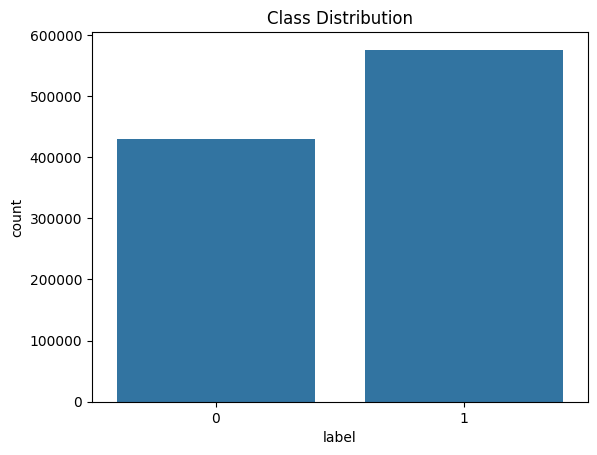

In [ ]:
sns.countplot(data=urls_df, x="label")
plt.title("Class Distribution")
plt.show()

# DeBERTa-v3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive

'20181007_214148 (1).jpg'     'Colab Notebooks'
'20181007_214148 (2).jpg'     'Color and Shape Recognition.coco.zip'
'20181007_214148 (3).jpg'     'Rehab Alharby CV (1).pdf'
'20181007_214148 (4).jpg'     'Rehab Alharby CV (2).pdf'
 20181007_214148.jpg	      'Rehab Alharby CV (3).pdf'
'20181007_214357 (1).jpg'     'Rehab Alharby CV(arabic).pdf'
'20181007_214357 (2).jpg'     'Rehab Alharby CV.pdf'
'20181007_214357 (3).jpg'     'S 8🐎'
'20181007_214357 (4).jpg'      test_sample.csv
'20181007_214357 (5).jpg'      train
'20181007_214357 (6).jpg'     'training letter (duration).pdf'
'20181007_214357 (7).jpg'     'Training letter.pdf'
 20181007_214357.jpg	       training_sample.csv
'Academic Transcribt(1).pdf'  'اعادة الدوري الاول (1).gsheet'
'Academic Transcribt.pdf'     'اعادة الدوري الاول.gsheet'
'best (1) (1).pt'	      'اعادة الدوري الاول.xlsx'
 Classroom		      'حل ربا .gdoc'


In [ ]:
import torch
torch.cuda.empty_cache()

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else " false")

GPU available: True
GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
!pip install transformers datasets scikit-learn accelerate -q

In [ ]:
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 64

train_urls, test_urls, train_labels, test_labels = train_test_split(
    urls_df["url"], urls_df["label"], test_size=0.3, random_state=42, stratify=urls_df["label"]
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class URLDataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_length):
        self.urls = list(urls)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
      encoding = self.tokenizer(
          self.urls[idx], truncation=True, padding="max_length",
          max_length=self.max_length, return_tensors="pt"
      )
      item = {key: val.squeeze(0) for key, val in encoding.items()}
      item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
      return item

train_dataset = URLDataset(train_urls, train_labels, tokenizer, MAX_LENGTH)
test_dataset = URLDataset(test_urls, test_labels, tokenizer, MAX_LENGTH)
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.den

Train: 704003 | Test: 301716


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }


import math
batch_size = 16
epochs = 5
steps_per_epoch = math.ceil(len(train_dataset) / batch_size)
warmup_steps = int(steps_per_epoch * epochs * 0.05)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/deberta_url_model",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-6,
    warmup_steps=warmup_steps,
    max_grad_norm=1.0,
    weight_decay=0.01,
    adam_epsilon=1e-6,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=False,
    bf16=False,
    seed=42,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.047639,0.088046,0.981473,0.979878,0.982603,0.981130


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.047639,0.088046,0.981473,0.979878,0.982603,0.981130
2,0.041907,0.054506,0.987028,0.986943,0.986548,0.986744
3,0.043684,0.039057,0.989351,0.988870,0.989394,0.989128
4,0.014384,0.040863,0.990342,0.989789,0.990509,0.990142
5,0.017001,0.037842,0.990617,0.990172,0.990675,0.990420


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=220005, training_loss=0.047709869694745576, metrics={'train_runtime': 5233.6272, 'train_samples_per_second': 672.577, 'train_steps_per_second': 42.037, 'total_flos': 1.1577143388095616e+17, 'train_loss': 0.047709869694745576, 'epoch': 5.0})

In [ ]:
trainer.evaluate()
results = trainer.evaluate()
print("\nFinal results:")
for key, val in results.items():
    print(f"   {key}: {val:.4f}" if isinstance(val, float) else f"   {key}: {val}")

trainer.save_model("/content/drive/MyDrive/deberta_url_model")
tokenizer.save_pretrained("/content/drive/MyDrive/deberta_url_model")
print("model saved succesfully")

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.017001,0.037842,5,0.990617,0.990172,0.990675,0.990420


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.017001,0.037842,5,0.990617,0.990172,0.990675,0.990420



Final results:
   eval_loss: 0.0378
   eval_accuracy: 0.9906
   eval_precision_macro: 0.9902
   eval_recall_macro: 0.9907
   eval_f1_macro: 0.9904


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model saved succesfully


Inference Time: 142.88 seconds


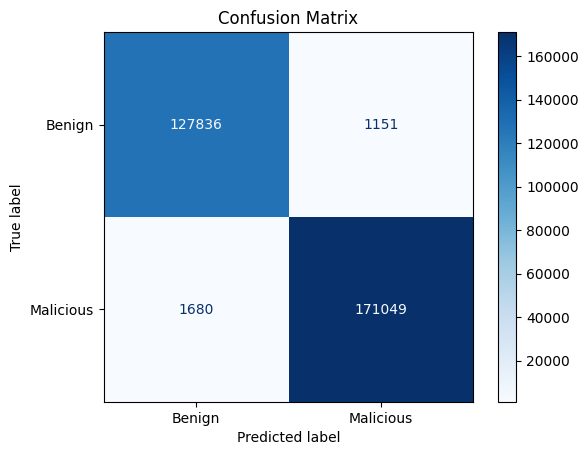

In [ ]:
# Measure inference time + Confusion Matrix
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

start_time = time.time()

predictions = trainer.predict(test_dataset)

end_time = time.time()
inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.2f} seconds")

# True and predicted labels
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malicious"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()